In [1]:
import pandas as pd

# Объединение двух csv

In [6]:
#Загрузим оба датасета
df_b = pd.read_csv('https://raw.githubusercontent.com/FragileMouse/flight-price-analysis/refs/heads/main/data/business.csv')
df_e = pd.read_csv('https://raw.githubusercontent.com/FragileMouse/flight-price-analysis/refs/heads/main/data/economy.csv')

In [7]:
#Добавим в каждый датасет колонку с классом
df_b['class'] = 'business'
df_e['class'] = 'economy'

In [130]:
#Объединим датасеты
df = pd.concat([df_b, df_e], axis=0, ignore_index=True)

# Первичный осмотр

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        300261 non-null  object
 1   airline     300261 non-null  object
 2   ch_code     300261 non-null  object
 3   num_code    300261 non-null  int64 
 4   dep_time    300261 non-null  object
 5   from        300261 non-null  object
 6   time_taken  300261 non-null  object
 7   stop        300261 non-null  object
 8   arr_time    300261 non-null  object
 9   to          300261 non-null  object
 10  price       300261 non-null  object
 11  class       300261 non-null  object
dtypes: int64(1), object(11)
memory usage: 27.5+ MB


In [132]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612",business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612",business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220",business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450",business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690",business


- 300 261 строка, 12 признаков
- Пропусков нет
- Проблема с типом данных

In [133]:
df['date'] = pd.to_datetime(df['date'], format = '%d-%m-%Y')

In [134]:
df['dep_time'] = pd.to_datetime(df['dep_time'], format='%H:%M').dt.time

In [135]:
df['time_taken'] = df['time_taken'].str.extract(r'^(\d+)h\s*(\d+)m$').fillna(0).astype(float).pipe(lambda x: x[0] * 60 + x[1]) #Будем измерять в минутах

In [136]:
#stop сейчас имеют лишние данные, мы пока преобразуем в ['non-stop ', '1-stop', '2+-stop']
df['stop'] = df['stop'].str.split('\n').str[0]

In [137]:
df['arr_time'] = pd.to_datetime(df['arr_time'], format='%H:%M').dt.time

In [138]:
df[~df['price'].str.match(r'^\d+,\d{3}$')] #Что-то странное творится

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
9192,2022-02-11,Vistara,UK,809,19:50:00,Delhi,1265.0,2+-stop,16:55:00,Kolkata,"1,14,434",business
9193,2022-02-11,Vistara,UK,809,19:50:00,Delhi,1265.0,2+-stop,16:55:00,Kolkata,"1,16,562",business
9359,2022-02-14,Vistara,UK,817,16:05:00,Delhi,1055.0,2+-stop,09:40:00,Kolkata,"1,00,395",business
9429,2022-02-15,Vistara,UK,963,08:50:00,Delhi,480.0,1-stop,16:50:00,Kolkata,"1,01,369",business
9430,2022-02-15,Vistara,UK,811,05:55:00,Delhi,655.0,2+-stop,16:50:00,Kolkata,"1,17,307",business
...,...,...,...,...,...,...,...,...,...,...,...,...
86808,2022-02-13,Vistara,UK,836,10:45:00,Chennai,580.0,1-stop,20:25:00,Bangalore,"1,07,597",business
89335,2022-02-13,Vistara,UK,838,21:05:00,Chennai,690.0,1-stop,08:35:00,Kolkata,"1,02,832",business
89415,2022-02-15,Vistara,UK,832,06:55:00,Chennai,950.0,1-stop,22:45:00,Kolkata,"1,02,384",business
89504,2022-02-17,Vistara,UK,838,21:05:00,Chennai,690.0,1-stop,08:35:00,Kolkata,"1,04,624",business


Посе небольшого исследования я выяснила, что вообще говоря 1,16,562 это 116562 рупии. Т.е. надо просто удалить запятые и можно преобразовывать к целому числу. В общем в индии особенная система.

In [139]:
df['price'] = df['price'].str.replace(',','').astype(int)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        300261 non-null  datetime64[ns]
 1   airline     300261 non-null  object        
 2   ch_code     300261 non-null  object        
 3   num_code    300261 non-null  int64         
 4   dep_time    300261 non-null  object        
 5   from        300261 non-null  object        
 6   time_taken  300261 non-null  float64       
 7   stop        300261 non-null  object        
 8   arr_time    300261 non-null  object        
 9   to          300261 non-null  object        
 10  price       300261 non-null  int64         
 11  class       300261 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [141]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,120.0,non-stop,20:00:00,Mumbai,25612,business
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,135.0,non-stop,21:15:00,Mumbai,25612,business
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,1485.0,1-stop,20:45:00,Mumbai,42220,business
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,1590.0,1-stop,23:55:00,Mumbai,44450,business
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,400.0,1-stop,23:55:00,Mumbai,46690,business


In [161]:
df.duplicated().sum()

np.int64(2)

In [162]:
df = df[df.duplicated() == False]

# Вопрос 1: Зависит ли цена от авиакомпании?

_


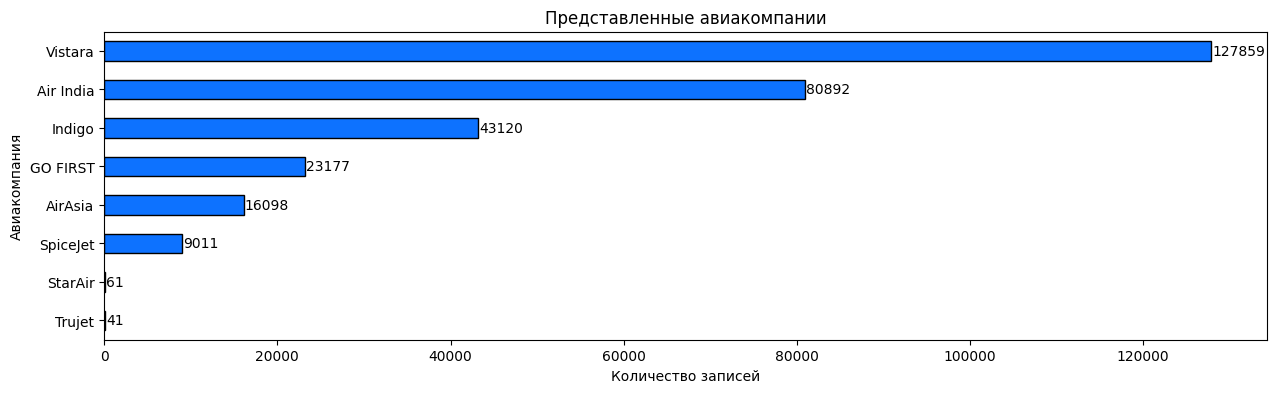

In [189]:
ax = df['airline'].value_counts(ascending=True).plot.barh(
    title='Представленные авиакомпании',
    xlabel='Количество записей',
    ylabel='Авиакомпания',
    color='#0D72FF',
    edgecolor='black',
    figsize=(15, 4)
)

ax.bar_label(ax.containers[0], padding=1)
print('_')

In [208]:
df.groupby('airline')['price'].describe().sort_values(by = '50%', ascending = False).round(2)

,count,mean,std,min,25%,50%,75%,max
airline,,,,,,,,
Vistara,127859.0,30396.54,25637.16,1714.0,6412.0,15543.0,55377.0,123071.0
Air India,80892.0,23507.02,20905.12,1526.0,5623.0,11520.0,45693.0,90970.0
SpiceJet,9011.0,6179.28,2999.63,1106.0,4197.0,5654.0,7412.0,34158.0
GO FIRST,23177.0,5651.93,2513.67,1105.0,4205.0,5336.0,6324.0,32803.0
Indigo,43120.0,5324.22,3268.89,1105.0,3219.0,4453.0,6489.0,31952.0
StarAir,61.0,4932.66,3487.87,2000.0,2115.0,4337.0,8582.0,17482.0
AirAsia,16098.0,4091.07,2824.06,1105.0,2361.0,3276.0,4589.0,31917.0
Trujet,41.0,3244.63,305.18,3124.0,3166.0,3196.0,3196.0,4844.0
